# Dynamic regret oracle on two controlled domains

**TL;DR.** Complete registered three-step nominal action trees expose the same hidden-velocity
mechanism in both controlled domains. Privileged kinematic state and a two-frame observation-only
history retain the full-history Bellman value on every enumerated node. The identical current
frame has both positive optimal-margin regret `rho_3` and positive sign obstruction `kappa_3`:
every common action is unsafe for at least one viable root in both domains. These are exhaustive
finite floating-point checks at recorded tolerance, not learned-model evidence or a
population/deployment certificate.

## Context & Methods

### Key assumptions

- Each tree contains two hand-selected roots, all three registered actions at every node, and all
  `3^3` deterministic nominal action sequences. Process noise is fixed to zero.
- A safe predecessor reaches each root algebraically under the nominal model. The roots were not
  sampled from the behavior-policy dataset; the cart speeds exceed its noise-free envelope.
- Safety is the worst current-state margin over the three-step path, with the closed convention
  `h >= 0`. The action set is finite and successors are singleton nominal transitions.
- Exact full-frame tuples are used directly as codes—no hashes or learned embeddings. Scene
  geometry has already been quantized by the configured 32-by-32 raster.
- `rho_s` is robust optimal-margin regret, not a safety defect. `kappa_s` separately measures
  first-action sign obstruction on viable fibers; global policy existence is checked by the
  finite common-safe-action Bellman characterization.
- Exact tuple equality and exhaustive branches do not imply exact arithmetic. Dynamics use binary
  floating point and trigonometry; all inequalities use the report's recorded tolerance.
- The result covers only the enumerated roots, horizon, action grid, and nominal dynamics. It does
  not cover the continuous population, Gaussian disturbances, model mismatch, or learned models.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.benchmarks.dynamic_oracle import (
    MEMORYLESS_PIXELS,
    PRIVILEGED_STATE,
    TWO_FRAME_HISTORY,
    audit_controlled_dynamic_oracle,
    build_controlled_dynamic_tree,
)
from latent_safety.learning import load_config

config_paths = {
    "cart": ROOT / "configs/e1_world_models/torch_pilot.toml",
    "pendulum": ROOT / "configs/e1_world_models/torch_pendulum_pilot.toml",
}
configs = {name: load_config(path).data for name, path in config_paths.items()}
trees = {
    name: build_controlled_dynamic_tree(config, horizon=3)
    for name, config in configs.items()
}
reports = {
    name: audit_controlled_dynamic_oracle(config, horizon=3)
    for name, config in configs.items()
}
print({
    "status": "finite_nominal_theorem_oracle_not_empirical_evidence",
    "domains": list(reports),
    "horizon": 3,
    "tolerances": {name: report.tolerance for name, report in reports.items()},
    "config_sha256": {name: report.config_sha256 for name, report in reports.items()},
    "training_support_status": {
        name: report.training_support_status for name, report in reports.items()
    },
    "repo_root": str(ROOT),
})

{'status': 'finite_nominal_theorem_oracle_not_empirical_evidence', 'domains': ['cart', 'pendulum'], 'horizon': 3, 'tolerances': {'cart': 1e-12, 'pendulum': 1e-12}, 'config_sha256': {'cart': '46997bc3fef0f3ca7f7789ff560ae90fac9732a6e9514919b8b8bf558d17d991', 'pendulum': '575d545e0a5d5e0087f777d3a6bc44f6c6e1eb60ba697c71fd9bc9ef68caf3d9'}, 'training_support_status': {'cart': 'constructed algebraically reachable nominal-state controls, not sampled from the behavior-policy dataset and not claimed to lie in its empirical support; the root velocities exceed the bounded noise-free cart generator envelope', 'pendulum': 'constructed algebraically reachable nominal-state controls, not sampled from the behavior-policy dataset; no empirical or analytical behavior-policy support coverage is claimed for these pendulum roots'}, 'repo_root': '/Users/carloschreiber/Desktop/Uni/Research/ETH X STANFORD/ethxstanfordresearch/LatentSafety'}


## Data

### 1. Verify tree completeness and the intended fibers

With two roots, three actions, and horizon three, the layer counts from zero to three remaining
controls must be `(54, 18, 6, 2)`. Each nonterminal history-action pair has exactly one successor,
so this is exhaustive for the declared deterministic model. At the roots, the current-frame code
must merge both histories, while state and two-frame observation-only codes must separate them.

In [2]:
tree_rows = []
for domain, tree in trees.items():
    remaining = tree.horizon
    roots = tree.root_histories
    code_counts = {
        representation: len({
            tree.codes_by_representation[representation][(remaining, root)]
            for root in roots
        })
        for representation in (
            PRIVILEGED_STATE,
            MEMORYLESS_PIXELS,
            TWO_FRAME_HISTORY,
        )
    }
    expected_successors = sum(
        len(tree.histories_by_remaining[step]) * len(tree.actions)
        for step in range(1, tree.horizon + 1)
    )
    tree_rows.append({
        "domain": domain,
        "node_count_by_remaining": tree.node_count_by_remaining,
        "total_histories": sum(tree.node_count_by_remaining),
        "successor_entries": len(tree.successors),
        "root_code_counts": code_counts,
        "fixture_version": tree.fixture_version,
        "config_sha256": tree.config_sha256,
        "population_certificate": tree.population_certificate,
    })
    assert tree.node_count_by_remaining == (54, 18, 6, 2)
    assert len(tree.successors) == expected_successors == 78
    assert code_counts[MEMORYLESS_PIXELS] == 1
    assert code_counts[PRIVILEGED_STATE] == 2
    assert code_counts[TWO_FRAME_HISTORY] == 2
    assert not tree.population_certificate

display(tree_rows)

[{'domain': 'cart',
  'node_count_by_remaining': (54, 18, 6, 2),
  'total_histories': 80,
  'successor_entries': 78,
  'root_code_counts': {'privileged_kinematic_state_exact': 2,
   'memoryless_rendered_frame_exact': 1,
   'two_frame_rendered_history_exact': 2},
  'fixture_version': 'two_domain_empty_common_safe_action_v1',
  'config_sha256': '46997bc3fef0f3ca7f7789ff560ae90fac9732a6e9514919b8b8bf558d17d991',
  'population_certificate': False},
 {'domain': 'pendulum',
  'node_count_by_remaining': (54, 18, 6, 2),
  'total_histories': 80,
  'successor_entries': 78,
  'root_code_counts': {'privileged_kinematic_state_exact': 2,
   'memoryless_rendered_frame_exact': 1,
   'two_frame_rendered_history_exact': 2},
  'fixture_version': 'two_domain_empty_common_safe_action_v1',
  'config_sha256': '575d545e0a5d5e0087f777d3a6bc44f6c6e1eb60ba697c71fd9bc9ef68caf3d9',
  'population_certificate': False}]

## Results

### 2. Stagewise regret, sign obstruction, retained viability, and bounds

`B_s` follows only successors reached by the constructed representation policy; the global bound
is the looser sum of maximum stage regrets. `delta_s*` is the finite midpoint error for
fiber/action Q ranges. `kappa_s > 0` means at least one viable fiber has no common safe first
action. The composition theorem requires `loss <= B <= global` and `rho <= 2 delta*`.

In [3]:
stage_rows = []
for domain, report in reports.items():
    for representation in report.representations:
        for stage in representation.stages:
            row = {
                "domain": domain,
                "representation": representation.representation,
                "remaining_steps": stage.remaining_steps,
                "fibers": stage.fiber_count,
                "rho_s": stage.rho_s,
                "kappa_s": stage.kappa_s,
                "delta_s_star": stage.delta_s_star,
                "realized_loss": stage.max_realized_policy_loss,
                "max_B_s": stage.max_path_bound_B,
                "global_sum_bound": stage.global_sum_bound,
                "full_history_viable": stage.full_history_viable_count,
                "minimax_policy_retained": (
                    stage.selected_policy_retained_viable_count
                ),
                "minimax_policy_retained_fraction": (
                    stage.selected_policy_retained_viable_fraction
                ),
                "least_violating_policy_retained": (
                    stage.first_action_safety_policy_retained_viable_count
                ),
                "least_violating_policy_retained_fraction": (
                    stage.first_action_safety_policy_retained_viable_fraction
                ),
                "viable_fibers_without_common_safe_action": (
                    stage.fibers_without_common_safe_action
                ),
            }
            stage_rows.append(row)
            assert stage.rho_s <= 2.0 * stage.delta_s_star + report.tolerance
            assert stage.max_realized_policy_loss <= (
                stage.max_path_bound_B + report.tolerance
            )
            assert stage.max_path_bound_B <= (
                stage.global_sum_bound + report.tolerance
            )
        assert representation.theorem_bound_holds
        assert representation.closed_endpoint_holds
        assert representation.global_sign_characterization_holds

display(stage_rows)

[{'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'remaining_steps': 1,
  'fibers': 18,
  'rho_s': 0.0,
  'kappa_s': 0.0,
  'delta_s_star': 0.0,
  'realized_loss': 0.0,
  'max_B_s': 0.0,
  'global_sum_bound': 0.0,
  'full_history_viable': 3,
  'minimax_policy_retained': 3,
  'minimax_policy_retained_fraction': 1.0,
  'least_violating_policy_retained': 3,
  'least_violating_policy_retained_fraction': 1.0,
  'viable_fibers_without_common_safe_action': 0},
 {'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'remaining_steps': 2,
  'fibers': 6,
  'rho_s': 0.0,
  'kappa_s': 0.0,
  'delta_s_star': 0.0,
  'realized_loss': 0.0,
  'max_B_s': 0.0,
  'global_sum_bound': 0.0,
  'full_history_viable': 2,
  'minimax_policy_retained': 2,
  'minimax_policy_retained_fraction': 1.0,
  'least_violating_policy_retained': 2,
  'least_violating_policy_retained_fraction': 1.0,
  'viable_fibers_without_common_safe_action': 0},
 {'domain': 'cart',
  'repres

### 3. Separate optimal-margin regret from retained viability

The root table directly checks the sign of the optimal value `V` and representation-policy value
`J`. The root-fiber table separately exposes common safe actions and `kappa_3`. In both domains the
memoryless fiber contains two viable histories but has no common safe first action, which is
stronger than failure of the particular minimax-margin policy.

In [4]:
root_rows = []
root_fiber_rows = []
summaries = {}
for domain, report in reports.items():
    for representation in report.representations:
        summaries[(domain, representation.representation)] = representation
        for outcome in representation.root_outcomes:
            root_rows.append({
                "domain": domain,
                "representation": representation.representation,
                "root": outcome.history_id,
                "V_optimal": outcome.optimal_value,
                "J_minimax_margin_policy": outcome.representation_policy_value,
                "J_least_violating_safety_policy": (
                    outcome.first_action_safety_policy_value
                ),
                "realized_loss": outcome.realized_policy_loss,
                "B": outcome.path_bound_B,
                "optimal_finite_horizon_viable": (
                    outcome.finite_horizon_viable_under_optimal_policy
                ),
                "minimax_policy_finite_horizon_viable": (
                    outcome.finite_horizon_viable_under_representation_policy
                ),
                "safety_policy_finite_horizon_viable": (
                    outcome.finite_horizon_viable_under_first_action_safety_policy
                ),
            })
        for fiber in representation.root_fiber_safety:
            root_fiber_rows.append({
                "domain": domain,
                "representation": representation.representation,
                "fiber_index": fiber.fiber_index,
                "histories": fiber.histories,
                "viable_histories": fiber.viable_histories,
                "common_safe_actions": fiber.common_safe_actions,
                "kappa_3": fiber.first_action_obstruction,
                "minimax_margin_action": fiber.optimal_margin_action,
                "least_violating_action": fiber.least_violating_safety_action,
                "exact_viability_preserving_policy_exists": (
                    representation.exact_viability_preserving_code_policy_exists
                ),
            })

cart_pixels = summaries[("cart", MEMORYLESS_PIXELS)]
pendulum_pixels = summaries[("pendulum", MEMORYLESS_PIXELS)]
for memoryless_summary in (cart_pixels, pendulum_pixels):
    root_stage = memoryless_summary.stages[-1]
    assert root_stage.kappa_s > 0.0
    assert root_stage.fibers_without_common_safe_action == 1
    assert memoryless_summary.root_fiber_safety[0].common_safe_actions == ()
    assert not memoryless_summary.exact_viability_preserving_code_policy_exists
    assert all(
        outcome.finite_horizon_viable_under_optimal_policy
        for outcome in memoryless_summary.root_outcomes
    )
for domain in reports:
    for representation in (PRIVILEGED_STATE, TWO_FRAME_HISTORY):
        summary = summaries[(domain, representation)]
        assert summary.exact_viability_preserving_code_policy_exists
        assert all(stage.kappa_s == 0.0 for stage in summary.stages)
        assert all(
            outcome.optimal_value == outcome.representation_policy_value
            for outcome in summary.root_outcomes
        )

display(root_rows)
display(root_fiber_rows)

[{'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'root': 'cart_incoming_left',
  'V_optimal': 0.02868620799999999,
  'J_minimax_margin_policy': 0.02868620799999999,
  'J_least_violating_safety_policy': 0.0038030079999998856,
  'realized_loss': 0.0,
  'B': 0.0,
  'optimal_finite_horizon_viable': True,
  'minimax_policy_finite_horizon_viable': True,
  'safety_policy_finite_horizon_viable': True},
 {'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'root': 'cart_incoming_right',
  'V_optimal': 0.017865087999999862,
  'J_minimax_margin_policy': 0.017865087999999862,
  'J_least_violating_safety_policy': 0.017865087999999862,
  'realized_loss': 0.0,
  'B': 0.0,
  'optimal_finite_horizon_viable': True,
  'minimax_policy_finite_horizon_viable': True,
  'safety_policy_finite_horizon_viable': True},
 {'domain': 'cart',
  'representation': 'memoryless_rendered_frame_exact',
  'root': 'cart_incoming_left',
  'V_optimal': 0.02868620799999999,
 

[{'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'fiber_index': 0,
  'histories': ('cart_incoming_left',),
  'viable_histories': ('cart_incoming_left',),
  'common_safe_actions': (1.0,),
  'kappa_3': 0.0,
  'minimax_margin_action': 1.0,
  'least_violating_action': 1.0,
  'exact_viability_preserving_policy_exists': True},
 {'domain': 'cart',
  'representation': 'privileged_kinematic_state_exact',
  'fiber_index': 1,
  'histories': ('cart_incoming_right',),
  'viable_histories': ('cart_incoming_right',),
  'common_safe_actions': (-1.0,),
  'kappa_3': 0.0,
  'minimax_margin_action': -1.0,
  'least_violating_action': -1.0,
  'exact_viability_preserving_policy_exists': True},
 {'domain': 'cart',
  'representation': 'memoryless_rendered_frame_exact',
  'fiber_index': 0,
  'histories': ('cart_incoming_left', 'cart_incoming_right'),
  'viable_histories': ('cart_incoming_left', 'cart_incoming_right'),
  'common_safe_actions': (),
  'kappa_3': 0.01798745600000007,
  

### 4. Visual check at the registered three-step horizon

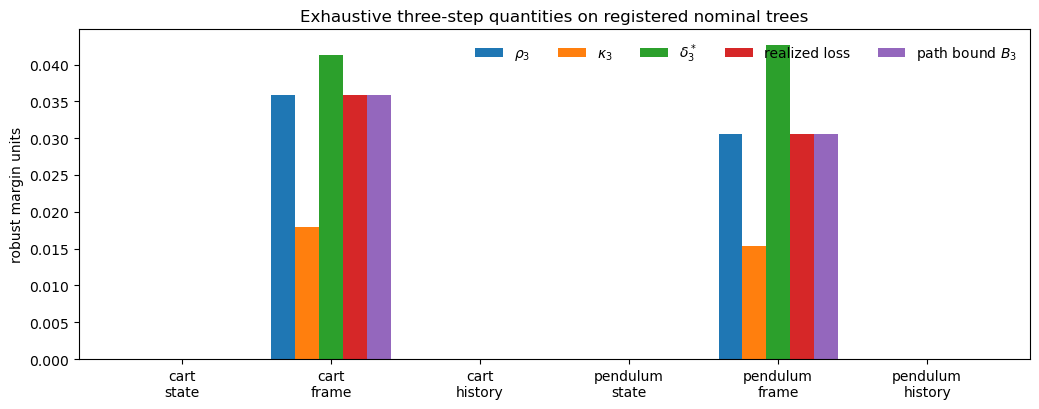

In [5]:
labels = []
rho_values = []
kappa_values = []
delta_values = []
loss_values = []
bound_values = []
for domain in ("cart", "pendulum"):
    for representation, short_name in (
        (PRIVILEGED_STATE, "state"),
        (MEMORYLESS_PIXELS, "frame"),
        (TWO_FRAME_HISTORY, "history"),
    ):
        stage = summaries[(domain, representation)].stages[-1]
        labels.append(f"{domain}\n{short_name}")
        rho_values.append(stage.rho_s)
        kappa_values.append(stage.kappa_s)
        delta_values.append(stage.delta_s_star)
        loss_values.append(stage.max_realized_policy_loss)
        bound_values.append(stage.max_path_bound_B)

x = np.arange(len(labels))
width = 0.16
fig, axis = plt.subplots(figsize=(10.5, 4.2))
axis.bar(x - 2.0 * width, rho_values, width, label=r"$\rho_3$")
axis.bar(x - width, kappa_values, width, label=r"$\kappa_3$")
axis.bar(x, delta_values, width, label=r"$\delta_3^*$")
axis.bar(x + width, loss_values, width, label="realized loss")
axis.bar(x + 2.0 * width, bound_values, width, label=r"path bound $B_3$")
axis.set_xticks(x, labels)
axis.set_ylabel("robust margin units")
axis.set_title("Exhaustive three-step quantities on registered nominal trees")
axis.legend(frameon=False, ncols=5)
fig.tight_layout()
plt.show()

## Takeaways

The finite oracle makes two distinct statements visible. Identical current pixels impose positive
robust optimal-margin regret in both dynamics. More strongly, each memoryless root fiber has
positive `kappa_3`: every common action is unsafe for at least one full-history-viable root. A
causal second frame alone removes both registered obstructions; no previous action is supplied.

This is a theorem/benchmark integration check, not a learned-representation result. It cannot be
used as paper evidence that an H4 neural encoder discovers velocity, nor as a population safety
certificate. The roots are constructed witnesses, not samples from the training distribution.
The next empirical question is whether trained history models reduce held-out
representation audits at matched world-model utility, with radii and model selection frozen on
validation data.